In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'],
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]


In [3]:
data=np.array(data)

In [4]:
data

array([['150', '7.0', '1', 'Apple'],
       ['120', '6.5', '0', 'Banana'],
       ['180', '7.5', '2', 'Orange'],
       ['155', '7.2', '1', 'Apple'],
       ['110', '6.0', '0', 'Banana'],
       ['190', '7.8', '2', 'Orange'],
       ['145', '7.1', '1', 'Apple'],
       ['115', '6.3', '0', 'Banana']], dtype='<U32')

In [5]:
X=data[:,:3].astype(float)

In [6]:
X

array([[150. ,   7. ,   1. ],
       [120. ,   6.5,   0. ],
       [180. ,   7.5,   2. ],
       [155. ,   7.2,   1. ],
       [110. ,   6. ,   0. ],
       [190. ,   7.8,   2. ],
       [145. ,   7.1,   1. ],
       [115. ,   6.3,   0. ]])

In [7]:
y_old=data[:,3]

In [8]:
y_old

array(['Apple', 'Banana', 'Orange', 'Apple', 'Banana', 'Orange', 'Apple',
       'Banana'], dtype='<U32')

In [9]:
label_map={"Apple":0,"Banana":1,"Orange":2}
y=np.array([label_map[x] for x in y_old])

In [10]:
y

array([0, 1, 2, 0, 1, 2, 0, 1])

In [11]:
def euclid_dist(x,y,n):
    s=0
    for i in range(n):
        s+=(x[i]-y[i])**2
    return s**(0.5)
    

In [12]:
class KNN:
    def __init__(self,k=3,metric="euclidean"):
        self.k=k
        self.metric=metric

    def fit(self,X,y):
        self.X=X
        self.y=y

    def predict(self,X_test):
        a=[]
        for i in range(len(X_test)):
            a.append(self.predict_one(X_test[i]))
        return a

    def predict_one(self,x):

        d = []
        b=[0]*len(set(self.y))
        
        for i in range(len(self.X)):
            if self.metric == "euclidean":
                dist=np.sqrt(np.sum((x - self.X[i])**2))
            elif self.metric == "manhattan":
                dist=np.sum(np.abs(x - self.X[i]))
            elif self.metric == "minkowski":
                p=3
                dist=np.sum(np.abs(x - self.X[i])**p)**(1/p)
            d.append((dist,self.y[i]))
        
        d.sort()
        
        c = [label for (dist, label) in d[:self.k]]
        for ele in c:
            b[ele]+=1
        m=b.index(max(b))
        for key,val in label_map.items():
            if val==m:
                ans=key
                break
        return ans
        
                
        

In [13]:
test_data = np.array([
    [118, 6.2, 0],  # Expected: Banana
    [160, 7.3, 1],  # Expected: Apple
    [185, 7.7, 2]   # Expected: Orange
])


In [14]:
#trying different values of k
for i in [1,3,5]:
    knn=KNN(k=i)
    knn.fit(X,y)
    res=knn.predict(test_data)
    print(res)

['Banana', 'Apple', 'Orange']
['Banana', 'Apple', 'Orange']
['Banana', 'Apple', 'Apple']


In [15]:
true_labels=['Banana','Apple','Orange']

In [16]:
#Function to check accuracy
def accuracy(true_labels,predicted):
    correct=0
    for i in range(len(true_labels)):
        if true_labels[i]==predicted[i]:
            correct+=1
    return correct/len(true_labels)

In [17]:
for i in [1,3,5]:
    knn=KNN(k=i)
    knn.fit(X,y)
    res=knn.predict(test_data)
    print(res)
    print(f"Accuracy={accuracy(true_labels,res)}")

['Banana', 'Apple', 'Orange']
Accuracy=1.0
['Banana', 'Apple', 'Orange']
Accuracy=1.0
['Banana', 'Apple', 'Apple']
Accuracy=0.6666666666666666


In [18]:
#Normalization
feature_mean=np.mean(X,axis=0)
feature_std=np.std(X,axis=0)
X=(X-feature_mean)/feature_std

In [19]:
X

array([[ 0.15815423,  0.13068205,  0.16012815],
       [-0.92633194, -0.74053163, -1.12089708],
       [ 1.24264041,  1.00189574,  1.44115338],
       [ 0.33890193,  0.47916753,  0.16012815],
       [-1.28782733, -1.61174531, -1.12089708],
       [ 1.6041358 ,  1.52462395,  1.44115338],
       [-0.02259346,  0.30492479,  0.16012815],
       [-1.10707964, -1.0890171 , -1.12089708]])

In [20]:
#Train test split
shuffled_indices=np.random.permutation(len(data))
train_size=0.8
split_point=int(len(data)*train_size)
train_indices=shuffled_indices[:split_point]
test_indices=shuffled_indices[split_point:]
train_data=data[train_indices]
test_data=data[test_indices]
print(f"Original shape: {data.shape}")
print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}") 

Original shape: (8, 4)
Train shape: (6, 4)
Test shape: (2, 4)


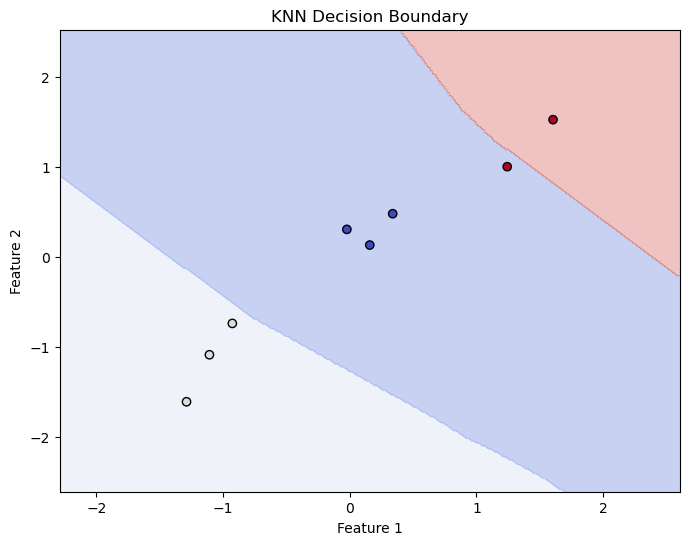

In [21]:
#Decision boundary visualization
knn=KNN(k=3)
knn.fit(X,y)

X_2d=X[:, :2]

x_min,x_max=X_2d[:,0].min()-1,X_2d[:,0].max()+1
y_min,y_max=X_2d[:,1].min()-1,X_2d[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(x_min,x_max,300),
    np.linspace(y_min,y_max,300)
)
grid_points = np.c_[xx.ravel(),yy.ravel()]
grid_points_full = np.c_[grid_points,np.zeros(len(grid_points))]
Z = knn.predict(grid_points_full)
reverse_map = {'Apple': 0, 'Banana': 1, 'Orange': 2}
Z = np.array([reverse_map[z] for z in Z])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X_2d[:,0],X_2d[:,1],c=y,edgecolors='k',cmap='coolwarm')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")

plt.show()

In [22]:
#for weighted knn, replace class function predict_one by the following :
def predict_one(self, x):
    d = []
    b = [0]*(max(self.y)+1)

    for i in range(len(self.X)):
        if self.metric == "euclidean":
            dist=np.sqrt(np.sum((x - self.X[i])**2))
        elif self.metric == "manhattan":
            dist=np.sum(np.abs(x - self.X[i]))
        elif self.metric == "minkowski":
            p=3
            dist=np.sum(np.abs(x - self.X[i])**p)**(1/p)
        d.append((dist, self.y[i]))

    d.sort()

    epsilon = 1e-5

    for dist, label in d[:self.k]:
        weight = 1 / (dist + epsilon)
        b[label] += weight

    m = b.index(max(b))

    for key, val in label_map.items():
        if val == m:
            ans = key
            break

    return ans